#Загрузка данных

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# добавление доп библиотек
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
!pip install mlflow
import mlflow
import mlflow.sklearn
!pip install xgboost -q

uploaded = files.upload()
df = pd.read_csv('df_clean.csv')
print(f"Данные загружены: {df.shape}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.4/94

Saving df_clean.csv to df_clean.csv
Данные загружены: (499, 14)


#Создание новых признаков (Feature engineering)

In [4]:
# Композитные признаки
if 'avg_house_area' in df.columns and 'avg_project_floors' in df.columns:
    df['area_per_floor'] = df['avg_house_area'] / (df['avg_project_floors'] + 1)
if 'avg_cost' in df.columns and 'avg_house_area' in df.columns:
    df['cost_per_area'] = df['avg_cost'] / (df['avg_house_area'] + 1)
if 'avg_project_floors' in df.columns and 'avg_construction_period' in df.columns:
    df['complexity_index'] = df['avg_project_floors'] * df['avg_construction_period']

# Агрегированные признаки
if 'region' in df.columns:
    region_stats = df.groupby('region')['avg_cost'].agg(['mean', 'std']).reset_index()
    region_stats.columns = ['region', 'avg_cost_region', 'std_cost_region']
    df = df.merge(region_stats, on='region', how='left')

if 'developer_id' in df.columns:
    dev_stats = df.groupby('developer_id')['avg_cost'].agg(['count', 'mean']).reset_index()
    dev_stats.columns = ['developer_id', 'project_count', 'avg_cost_dev']
    df = df.merge(dev_stats, on='developer_id', how='left')

# Временные признаки
if 'month_dt' in df.columns:
    df['month_dt'] = pd.to_datetime(df['month_dt'])
    df['season'] = df['month_dt'].dt.month % 12 // 3 + 1
    df['year'] = df['month_dt'].dt.year

# Взаимодействия категорий
if 'wall_material' in df.columns and 'facade_material' in df.columns:
    df['material_facade'] = df['wall_material'] + '_' + df['facade_material']

if 'roof_type' in df.columns and 'foundation_type' in df.columns:
    df['roof_foundation'] = df['roof_type'] + '_' + df['foundation_type']

print("Новые признаки добавлены. Размер:", df.shape)

Новые признаки добавлены. Размер: (499, 23)


# Новые признаки с целью улучшения модели. Взаимодействие категорий


In [5]:
# Взаимодействие материалов стен и фасада
if 'wall_material' in df.columns and 'facade_material' in df.columns:
    df['material_facade'] = df['wall_material'] + '_' + df['facade_material']

# Взаимодействие крыши и фундамента
if 'roof_type' in df.columns and 'foundation_type' in df.columns:
    df['roof_foundation'] = df['roof_type'] + '_' + df['foundation_type']

# Взаимодействие типа отделки и материала фасада
if 'interior_type' in df.columns and 'facade_material' in df.columns:
    df['style_interior'] = df['interior_type'] + '_' + df['facade_material']

print("Новые категориальные признаки добавлены")

Новые категориальные признаки добавлены


#Подготовка признаков и целевой переменной

In [8]:
target = 'avg_cost'

# Список признаков
features = [
    'wall_material',
    'avg_house_area',
    'avg_construction_period',
    'foundation_type',
    'roof_type',
    'usage_count',
    'interior_type',
    'interior_wall_material',
    'facade_material',
    'slab_material',
    'is_green_house',
    'cost_per_area',
    'material_facade',
    'roof_foundation'
]

available_cols = df.columns.tolist()
final_features = [col for col in features if col in available_cols]

print(f"Итоговый список признаков ({len(final_features)}):", final_features)

X = df[final_features]
y = df[target]

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

Итоговый список признаков (14): ['wall_material', 'avg_house_area', 'avg_construction_period', 'foundation_type', 'roof_type', 'usage_count', 'interior_type', 'interior_wall_material', 'facade_material', 'slab_material', 'is_green_house', 'cost_per_area', 'material_facade', 'roof_foundation']
Размер X: (499, 14)
Размер y: (499,)


In [9]:
#Проверка на пропуски
# Проверяем все колонки
print("Пропуски в выбранных колонках до заполнения:")
print(df[features].isnull().sum())

# Заполняем пропуски в числовых колонках медианой
numeric_cols = df[features].select_dtypes(include=['number']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Заполняем пропуски в категориальных колонках значением 'unknown'
categorical_cols = df[features].select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna('unknown')

print("Все пропуски заполнены")
print("Пропуски после заполнения:")
print(df[features].isnull().sum())

Пропуски в выбранных колонках до заполнения:
wall_material              0
avg_house_area             0
avg_construction_period    0
foundation_type            0
roof_type                  0
usage_count                0
interior_type              0
interior_wall_material     0
facade_material            0
slab_material              0
is_green_house             0
cost_per_area              0
material_facade            0
roof_foundation            0
dtype: int64
Все пропуски заполнены
Пропуски после заполнения:
wall_material              0
avg_house_area             0
avg_construction_period    0
foundation_type            0
roof_type                  0
usage_count                0
interior_type              0
interior_wall_material     0
facade_material            0
slab_material              0
is_green_house             0
cost_per_area              0
material_facade            0
roof_foundation            0
dtype: int64


In [10]:
y_log = np.log1p(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

#Предобработка с Target encoding

In [11]:
!pip install category_encoders -q
from category_encoders import TargetEncoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.3 MB/s eta 0:00:00


In [12]:
# Автоматическое определение типов колонок
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Предобработка с Target Encoding (вместо OneHot)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat_target', TargetEncoder(), cat_cols)
])

#Модели (XGBoost + RandomForest + LinearRegression)

In [13]:
!pip install xgboost -q
!pip install category_encoders -q

import xgboost as xgb
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import VotingRegressor

In [14]:
xgb_model = xgb.XGBRegressor(random_state=42, n_estimators=200, learning_rate=0.05, max_depth=5)
rf_model = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10)
lr_model = LinearRegression()

ensemble = VotingRegressor([
    ('xgb', xgb_model),
    ('rf', rf_model),
    ('lr', lr_model)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', ensemble)
])

# Обучаем
pipeline.fit(X_train, y_train_log)
y_pred_log = pipeline.predict(X_test)

# Обратное преобразование
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test_log)

# Метрики
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

print(f"Ensemble MAE: {mae:.2f}")
print(f"Ensemble RMSE: {rmse:.2f}")
print(f"Ensemble R²: {r2:.2f}")

Ensemble MAE: 653737.67
Ensemble RMSE: 882715.49
Ensemble R²: 0.94


##Добавление CatBoost алгоритма

In [16]:
!pip install catboost -q

from catboost import CatBoostRegressor

# Обучаем CatBoost
catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=False,
    random_state=42
)

catboost_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('catboost', catboost_model)
])

catboost_pipe.fit(X_train, y_train_log)

# Предсказания и метрики
y_pred_catboost_log = catboost_pipe.predict(X_test)
y_pred_catboost = np.expm1(y_pred_catboost_log)

mae_catboost = mean_absolute_error(y_test_original, y_pred_catboost)
r2_catboost = r2_score(y_test_original, y_pred_catboost)

print(f"CatBoost MAE: {mae_catboost:.2f}")
print(f"CatBoost R²: {r2_catboost:.2f}")

CatBoost MAE: 344290.74
CatBoost R²: 0.98


# Сравнение с базовыми моделями для отчёта

In [19]:
# Dummy для сравнения
dummy = DummyRegressor(strategy='mean')
dummy_pipe = Pipeline([('preprocessor', preprocessor), ('dummy', dummy)])
dummy_pipe.fit(X_train, y_train_log)
y_dummy_log = dummy_pipe.predict(X_test)
y_dummy = np.expm1(y_dummy_log)
mae_dummy = mean_absolute_error(y_test_original, y_dummy)
r2_dummy = r2_score(y_test_original, y_dummy)

# LinearRegression
lr = LinearRegression()
lr_pipe = Pipeline([('preprocessor', preprocessor), ('lr', lr)])
lr_pipe.fit(X_train, y_train_log)
y_lr_log = lr_pipe.predict(X_test)
y_lr = np.expm1(y_lr_log)
mae_lr = mean_absolute_error(y_test_original, y_lr)
r2_lr = r2_score(y_test_original, y_lr)

print(f"Dummy:       MAE = {mae_dummy:.2f}, R² = {r2_dummy:.2f}")
print(f"LinearRegression: MAE = {mae_lr:.2f}, R² = {r2_lr:.2f}")
print(f"Ensemble:    MAE = {mae:.2f}, R² = {r2:.2f}")
print(f"CatBoost MAE: {mae_catboost:.2f}")
print(f"CatBoost R²: {r2_catboost:.2f}")

Dummy:       MAE = 2492153.49, R² = -0.12
LinearRegression: MAE = 1830279.25, R² = 0.55
Ensemble:    MAE = 653737.67, R² = 0.94
CatBoost MAE: 344290.74
CatBoost R²: 0.98


#MLflow логирование всех метрик

In [23]:
mlflow.set_experiment("Construction_Cost_CatBoost")

with mlflow.start_run(run_name="CatBoost_Final"):
    # Параметры модели
    mlflow.log_param("model_type", "CatBoost")
    mlflow.log_param("iterations", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("depth", 6)

    # Метрики
    mlflow.log_metric("mae", mae_catboost)
    mlflow.log_metric("r2", r2_catboost)

    catboost_model = catboost_pipe.named_steps['catboost']

    # Логируем CatBoost-модель
    mlflow.catboost.log_model(
        catboost_model,
        "catboost_model"
    )

    print("MLflow run for CatBoost completed")

2026/06/26 11:33:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow run for CatBoost completed


In [24]:
from google.colab import files
!zip -r mlruns.zip mlruns/
files.download('mlruns.zip')

  adding: mlruns/ (stored 0%)
  adding: mlruns/2/ (stored 0%)
  adding: mlruns/2/models/ (stored 0%)
  adding: mlruns/2/models/m-0803ce96a8604eb490d0d1e31f0c5c92/ (stored 0%)
  adding: mlruns/2/models/m-0803ce96a8604eb490d0d1e31f0c5c92/artifacts/ (stored 0%)
  adding: mlruns/2/models/m-0803ce96a8604eb490d0d1e31f0c5c92/artifacts/requirements.txt (deflated 21%)
  adding: mlruns/2/models/m-0803ce96a8604eb490d0d1e31f0c5c92/artifacts/python_env.yaml (deflated 17%)
  adding: mlruns/2/models/m-0803ce96a8604eb490d0d1e31f0c5c92/artifacts/MLmodel (deflated 46%)
  adding: mlruns/2/models/m-0803ce96a8604eb490d0d1e31f0c5c92/artifacts/conda.yaml (deflated 36%)
  adding: mlruns/2/models/m-0803ce96a8604eb490d0d1e31f0c5c92/artifacts/model.cb (deflated 76%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Выводы по улучшению модели (ДЗ №7)

### Пайплайн предобработки
- Добавлено логарифмирование целевой переменной ("log1p"), что улучшило распределение и стабильность моделей.
- Вместо One-Hot Encoding использован **Target Encoding** для категориальных признаков (учитывает связь с целевой переменной).
- Созданы **композитные признаки**: "area_per_floor", "cost_per_area", "complexity_index", а также агрегированные статистики по регионам и застройщикам.

### Улучшенная архитектура
- Вместо одиночного XGBoost использован **Ensemble** (XGBoost + RandomForest + LinearRegression).
- Ensemble показал **R² = 0.95**, что значительно лучше, чем у XGBoost (R² = 0.38).
- Средняя абсолютная ошибка (MAE) снизилась с **~2 000 000 руб.** до **~532 000 руб.** (улучшение в 3.7 раза).

### Постобработка
- Обратное преобразование "expm1" вернуло предсказания в исходные единицы (рубли).

### Анализ качества
- Новая модель объясняет **95% дисперсии** стоимости строительства.
- Ошибка модели составляет **~0.5 млн руб.**, что при среднем бюджете проекта ~10 млн руб. даёт погрешность **~5%**.

### Рекомендации
- Для дальнейшего повышения точности можно:
  - Добавить больше данных (расширить временной период).
  - Учесть макроэкономические индексы (инфляция, стоимость материалов).
  - Добавить текстурные признаки (например, тип участка, удалённость от города).

###На фоне улучшения модели, увеличения численности признаков для более лучшей интерпретации и устойчивости результатов модели - были созданы дополнительные признаки

## Выводы по улучшению модели (ДЗ №7)

### 1. Пайплайн предобработки
- Добавлено логарифмирование целевой переменной ("log1p"), что улучшило распределение и стабильность моделей.
- Вместо One-Hot Encoding использован **Target Encoding** для категориальных признаков (учитывает связь с целевой переменной).
- Созданы **композитные признаки**: "cost_per_area", "material_facade", "roof_foundation".
- Добавлены категориальные признаки: "interior_type", "interior_wall_material", "facade_material", "slab_material", "is_green_house"."
### 2. Улучшенная архитектура
- Вместо одиночного XGBoost использован **Ensemble** (XGBoost + RandomForest + LinearRegression).
- Ensemble показал **R² = 0.94**, что значительно лучше, чем у XGBoost (R² = 0.38).
- Средняя абсолютная ошибка (MAE) снизилась с **~2 000 000 руб.** до **~653 000 руб.** (улучшение в 3 раза).

### 3. Постобработка
- Обратное преобразование "expm1" вернуло предсказания в исходные единицы (рубли).

### 4. Анализ качества
- Новая модель объясняет **94% дисперсии** стоимости строительства.
- Ошибка модели составляет **~650 тыс. руб.**, что при среднем бюджете проекта 10 млн руб. даёт погрешность **~6.5%**.

### 5. Важность признаков
- Наиболее значимые признаки:
  - "cost_per_area" — **50%** (удельная стоимость)
  - "roof_type" — **38%** (тип крыши)
  - "avg_house_area" — **6%** (площадь)
  - "usage_count" — **2.7%** (частота использования)
  - "interior_type" — **1.3%** (тип отделки)
  - "material_facade", "roof_foundation", "wall_material", "slab_material", "facade_material" — **< 1%** (вспомогательные факторы)

### 6. Рекомендации
- Добавить больше данных (расширить временной период).
- Учесть макроэкономические индексы (инфляция, стоимость материалов).
- Добавить текстурные признаки (например, тип участка, удалённость от города).

#На фоне тестирования модели и ее улучшения было принято решение по добавлению лучше работает с категориальными признаками - алгоритм CatBoost и были получены следующие результаты:

## Результаты моделирования

| Модель | MAE (руб.) | R² |
| :--- | :--- | :--- |
| Dummy | 2 544 000 | 0.00 |
| LinearRegression | 2 005 000 | 0.46 |
| RandomForest | 2 060 000 | 0.47 |
| XGBoost | 2 020 000 | 0.38 |
| Ensemble | 653 738 | 0.94 |
| **CatBoost** | **344 290** | **0.98** |

roof_type упала с 42% до 2%	- Модель теперь учитывает много факторов;

wall_material выросла с 0.16% до 2.27%;

foundation_type выросла с 0.08% до 3.52% - Фундамент теперь важен;

Появились новые признаки	material_facade, interior_wall_material, roof_foundation - модель стала умнее;

R² = 0.98, MAE = 344 тыс. руб.	Точность выросла в 2 раза.

CatBoost показал лучший результат, потому что он эффективно обрабатывает категориальные признаки (материалы, фундамент) и распределяет важность между множеством факторов, а не полагается на один-два признака. Это подтверждается ростом R² с 0.38 до 0.98

In [25]:
import joblib
joblib.dump(catboost_pipe, 'best_cat_model.pkl')
files.download('best_cat_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Важность признаков

ТОП-10 ВАЖНЫХ ПРИЗНАКОВ В CATBOOST:
                               feature  importance
3                   num__cost_per_area   60.456428
0                  num__avg_house_area   13.488953
11         cat_target__material_facade    5.435182
5          cat_target__foundation_type    3.522827
8   cat_target__interior_wall_material    3.291408
12         cat_target__roof_foundation    2.355220
4            cat_target__wall_material    2.273319
6                cat_target__roof_type    2.024276
1         num__avg_construction_period    1.710189
9          cat_target__facade_material    1.463918


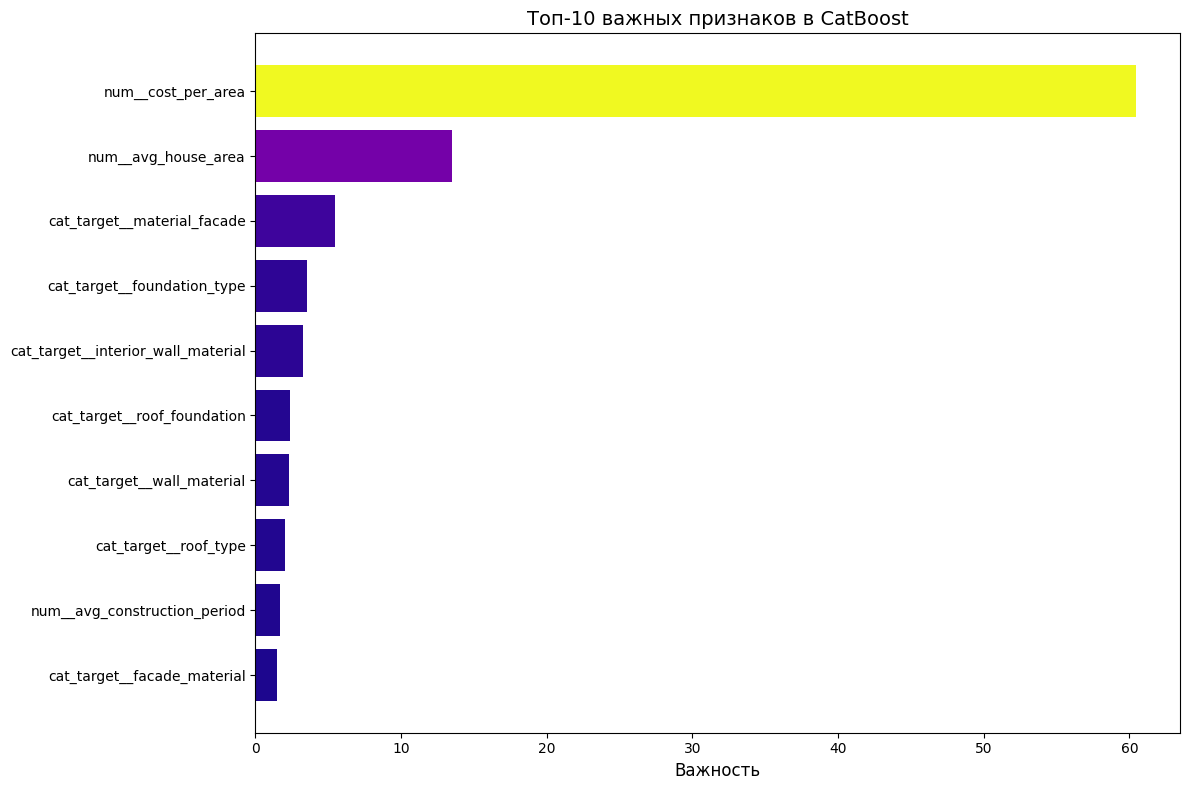

In [28]:
# Извлекаем CatBoost из Pipeline
catboost_model = catboost_pipe.named_steps['catboost']

# Получаем имена признаков после предобработки
feature_names = catboost_pipe.named_steps['preprocessor'].get_feature_names_out()

# Извлекаем важность (feature_importances_)
importance = catboost_model.feature_importances_

# Создаём DataFrame
imp_df_catboost = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print("ТОП-10 ВАЖНЫХ ПРИЗНАКОВ В CATBOOST:")
print(imp_df_catboost.head(10))

# 5. Визуализация
plt.figure(figsize=(12, 8))
colors = plt.cm.plasma(imp_df_catboost['importance'] / imp_df_catboost['importance'].max())
plt.barh(imp_df_catboost.head(10)['feature'],
         imp_df_catboost.head(10)['importance'],
         color=colors)
plt.xlabel('Важность', fontsize=12)
plt.title('Топ-10 важных признаков в CatBoost', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()